In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
sns.set()

In [2]:
df=pd.read_csv('DS_DATA.csv')

In [3]:
df

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,No Urgent Place,Alone,Sunny,55,Restaurant(<20),1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,Coffee House,1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,Carry out & Take away,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,Carry out & Take away,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,Coffee House,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,Bar,1d,Male,26,Single,0,...,never,1~3,4~8,1~3,1,1,1,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   coupon                12684 non-null  object
 5   expiration            12684 non-null  object
 6   gender                12684 non-null  object
 7   age                   12684 non-null  object
 8   maritalStatus         12684 non-null  object
 9   has_children          12684 non-null  int64 
 10  education             12684 non-null  object
 11  occupation            12684 non-null  object
 12  income                12684 non-null  object
 13  car                   108 non-null    object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

In [5]:
df.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df[df.duplicated(keep=False)]

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
23,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4~8,4~8,less1,1,0,0,0,1,0
30,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4~8,4~8,less1,1,0,0,0,1,0
89,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,1~3,less1,1~3,1,0,0,0,1,1
96,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,1~3,less1,1~3,1,0,0,0,1,1
155,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,26,Single,0,...,gt8,gt8,gt8,gt8,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10592,No Urgent Place,Kid(s),Sunny,80,Coffee House,1d,Female,26,Married partner,1,...,never,less1,less1,less1,1,0,0,0,1,0
10669,No Urgent Place,Kid(s),Sunny,80,Coffee House,1d,Female,26,Married partner,1,...,never,1~3,less1,never,1,0,0,0,1,0
10670,No Urgent Place,Kid(s),Sunny,80,Coffee House,1d,Female,26,Married partner,1,...,never,1~3,less1,never,1,0,0,0,1,0
10707,No Urgent Place,Kid(s),Sunny,80,Coffee House,1d,Female,41,Single,1,...,less1,1~3,1~3,less1,1,0,0,0,1,0


In [7]:
df.duplicated().sum()

np.int64(291)

In [8]:
#Counting duplicated rows
df_counts = df.value_counts().reset_index(name='count')
df_counts

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?),count
0,No Urgent Place,Friend(s),Snowy,30,Carry out & Take away,1d,Male,21,Single,0,...,1~3,less1,less1,1,1,0,0,1,1,2
1,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,26,Single,0,...,4~8,1~3,never,1,0,0,0,1,0,2
2,Home,Alone,Snowy,30,Coffee House,1d,Female,26,Single,0,...,1~3,1~3,1~3,1,1,0,0,1,0,1
3,Home,Alone,Snowy,30,Coffee House,1d,Male,21,Single,0,...,1~3,less1,less1,1,1,0,0,1,0,1
4,Home,Alone,Snowy,30,Restaurant(20-50),2h,Female,26,Single,0,...,1~3,1~3,1~3,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,Work,Alone,Sunny,80,Restaurant(20-50),1d,Female,41,Married partner,1,...,1~3,1~3,less1,1,1,0,0,1,0,1
102,Work,Alone,Sunny,80,Restaurant(20-50),1d,Male,26,Married partner,1,...,1~3,1~3,less1,1,1,0,0,1,1,1
103,Work,Alone,Sunny,80,Restaurant(20-50),1d,Male,26,Single,0,...,4~8,1~3,never,1,1,0,0,1,0,1
104,Work,Alone,Sunny,80,Restaurant(<20),1d,Female,26,Single,0,...,1~3,1~3,1~3,1,0,0,1,0,1,1


In [9]:
#As its 2, keeping duplicate values.
df_counts['count'].max()

2

In [10]:
df.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Accept(Y/N?)                0
dtype: int64

In [11]:
df['car'].unique()

array([nan, 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

In [12]:
#99% of Data is missing
df=df.drop(columns='car',axis=1)

In [13]:
#Seperating cat and num columns to fill null values
cat=df.select_dtypes(include=object)
num=df.select_dtypes(exclude=object)
num=num.drop(columns='Accept(Y/N?)', axis=1)


In [14]:
SI_Num=SimpleImputer(strategy='mean')
SI_Cat=SimpleImputer(strategy='most_frequent')
df1=SI_Num.fit_transform(num)
df2=SI_Cat.fit_transform(cat)



In [15]:
df1=pd.DataFrame(df1,columns=num.columns)
df2=pd.DataFrame(df2,columns=cat.columns)

In [16]:
df_new=pd.concat([df1,df2,df['Accept(Y/N?)']], axis=1)

In [17]:
df_new.isnull().sum()

temperature             0
has_children            0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
destination             0
passanger               0
weather                 0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
Accept(Y/N?)            0
dtype: int64

<Axes: >

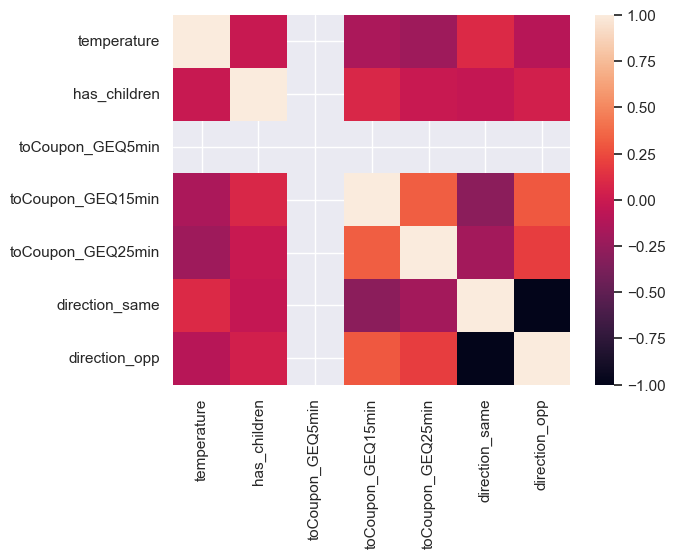

In [18]:
corr = num.corr()
plt.figure()
sns.heatmap(corr)

In [19]:
#Checking the data points at a granular level
for i in df_new.columns:
    print(i)
    print('')
    print(set(df_new[i]))
    print('')
    print('-------------------------')

temperature

{80.0, 30.0, 55.0}

-------------------------
has_children

{0.0, 1.0}

-------------------------
toCoupon_GEQ5min

{1.0}

-------------------------
toCoupon_GEQ15min

{0.0, 1.0}

-------------------------
toCoupon_GEQ25min

{0.0, 1.0}

-------------------------
direction_same

{0.0, 1.0}

-------------------------
direction_opp

{0.0, 1.0}

-------------------------
destination

{'No Urgent Place', 'Work', 'Home'}

-------------------------
passanger

{'Kid(s)', 'Friend(s)', 'Partner', 'Alone'}

-------------------------
weather

{'Rainy', 'Sunny', 'Snowy'}

-------------------------
coupon

{'Restaurant(<20)', 'Carry out & Take away', 'Coffee House', 'Bar', 'Restaurant(20-50)'}

-------------------------
expiration

{'1d', '2h'}

-------------------------
gender

{'Female', 'Male'}

-------------------------
age

{'36', '26', '46', '31', '50plus', '41', 'below21', '21'}

-------------------------
maritalStatus

{'Single', 'Divorced', 'Unmarried partner', 'Widowed', 'Marr

In [20]:
df_new2=df_new

In [21]:
df_new2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature           12684 non-null  float64
 1   has_children          12684 non-null  float64
 2   toCoupon_GEQ5min      12684 non-null  float64
 3   toCoupon_GEQ15min     12684 non-null  float64
 4   toCoupon_GEQ25min     12684 non-null  float64
 5   direction_same        12684 non-null  float64
 6   direction_opp         12684 non-null  float64
 7   destination           12684 non-null  object 
 8   passanger             12684 non-null  object 
 9   weather               12684 non-null  object 
 10  coupon                12684 non-null  object 
 11  expiration            12684 non-null  object 
 12  gender                12684 non-null  object 
 13  age                   12684 non-null  object 
 14  maritalStatus         12684 non-null  object 
 15  education          

In [22]:
#Manual Label Encoding

df_new2['expiration']=df_new2['expiration'].replace(['2h', '1d'],[2,24])
df_new2['age']=df_new2['age'].replace(['36', '50plus', '31', 'below21', '21', '46', '26', '41'],[4,7,3,0,1,6,2,5])
df_new2['Bar']=df_new2['Bar'].replace(['never', 'gt8', '1~3', '4~8', 'less1'],[0,4,2,3,1])
df_new2['CoffeeHouse']=df_new2['CoffeeHouse'].replace(['never', 'gt8', '1~3', '4~8', 'less1'],[0,4,2,3,1])
df_new2['CarryAway']=df_new2['CarryAway'].replace(['never', 'gt8', '1~3', '4~8', 'less1'],[0,4,2,3,1])
df_new2['RestaurantLessThan20']=df_new2['RestaurantLessThan20'].replace(['never', 'gt8', '1~3', '4~8', 'less1'],[0,4,2,3,1])
df_new2['Restaurant20To50']=df_new2['Restaurant20To50'].replace(['never', 'gt8', '1~3', '4~8', 'less1'],[0,4,2,3,1])
df_new2['education'] = df_new2['education'].replace(['Some High School', 'High School Graduate', 'Some college - no degree',
                                        'Associates degree', 'Bachelors degree', 'Graduate degree (Masters or Doctorate)'], [0, 1, 2, 3, 4, 5])



In [23]:
income_map ={
 'Less than $12500': 0,
 '$12500 - $24999': 1,
 '$25000 - $37499': 2,
 '$37500 - $49999': 3,
 '$50000 - $62499': 4,
 '$62500 - $74999': 5,
 '$75000 - $87499': 6,
 '$87500 - $99999': 7,
 '$100000 or More': 8
}
df_new2['income'] = df_new2['income'].replace(income_map)

In [24]:
for i in df_new2.columns:
    print(i)
    print('')
    print(set(df_new2[i]))
    print('')
    print('-------------------------')

temperature

{80.0, 30.0, 55.0}

-------------------------
has_children

{0.0, 1.0}

-------------------------
toCoupon_GEQ5min

{1.0}

-------------------------
toCoupon_GEQ15min

{0.0, 1.0}

-------------------------
toCoupon_GEQ25min

{0.0, 1.0}

-------------------------
direction_same

{0.0, 1.0}

-------------------------
direction_opp

{0.0, 1.0}

-------------------------
destination

{'No Urgent Place', 'Work', 'Home'}

-------------------------
passanger

{'Kid(s)', 'Friend(s)', 'Partner', 'Alone'}

-------------------------
weather

{'Rainy', 'Sunny', 'Snowy'}

-------------------------
coupon

{'Restaurant(<20)', 'Carry out & Take away', 'Coffee House', 'Bar', 'Restaurant(20-50)'}

-------------------------
expiration

{24, 2}

-------------------------
gender

{'Female', 'Male'}

-------------------------
age

{0, 1, 2, 3, 4, 5, 6, 7}

-------------------------
maritalStatus

{'Single', 'Divorced', 'Unmarried partner', 'Widowed', 'Married partner'}

-----------------------

In [25]:
df_new['toCoupon_GEQ5min'].unique()

array([1.])

In [26]:
#Drpping as it is constant
df_new=df_new.drop(columns=['toCoupon_GEQ5min'],axis=1)

In [27]:
x=df_new2.drop(columns='Accept(Y/N?)',axis=1)
y=df_new2['Accept(Y/N?)']

In [28]:
x_train1,x_test1,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=22,stratify=y)

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
nominal=['destination','passanger', 'weather', 'coupon','gender','maritalStatus','occupation']
encoder = OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)

x_train2 = pd.DataFrame(
    encoder.fit_transform(x_train1[nominal]),
    columns=encoder.get_feature_names_out(nominal),
    index=x_train1.index
)

# Transform test using same encoder
x_test2 = pd.DataFrame(
    encoder.transform(x_test1[nominal]),
    columns=encoder.get_feature_names_out(nominal),
    index=x_test1.index)

In [32]:
x_train = pd.concat([x_train1.drop(columns=nominal), x_train2], axis=1)
x_test = pd.concat([x_test1.drop(columns=nominal), x_test2], axis=1)

In [34]:
x_train.columns = x_train.columns.astype(str).str.replace('[\[\]<>]', '', regex=True)
x_test.columns = x_test.columns.astype(str).str.replace('[\[\]<>]', '', regex=True)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
# evaluation matrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,ConfusionMatrixDisplay

      Method Used  Accuracy
0  LogitRegession  0.691368
1           Dtree  0.714229
2         RForest  0.767442
3             XGB  0.785574
4             KNN  0.667324
5             SVM  0.607016
6             NBT  0.638549
7          Voting  0.778084
Axes(0.125,0.11;0.775x0.77)


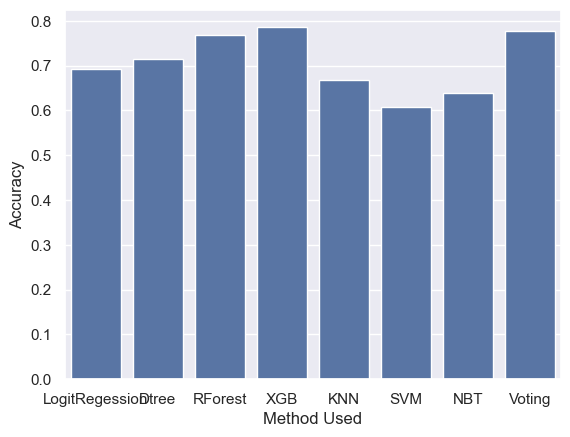

In [36]:
list_met = []
list_accuracy = []

# LogisticRegression
logit = LogisticRegression()
logit = logit.fit(x_train, y_train)
y_pred_lr = logit.predict(x_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# DecisionTree
dtree = DecisionTreeClassifier()
dtree = dtree.fit(x_train, y_train)
y_pred_dt = dtree.predict(x_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# RandomForest
rforest = RandomForestClassifier()
rforest = rforest.fit(x_train, y_train)
y_pred_rf = rforest.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# XGBoost
xgboost = XGBClassifier(colsample_bytree=0.7, learning_rate=0.1, max_depth= 9, n_estimators=300, reg_lambda=10, subsample=0.8)
xgboost = xgboost.fit(x_train, y_train)
y_pred_xg = xgboost.predict(x_test)
accuracy_xg = accuracy_score(y_test, y_pred_xg)

# KNN
knn = KNeighborsClassifier()
knn = knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# KNN
knn = KNeighborsClassifier()
knn = knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# SVM
svm = SVC()
svm = svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Naive Based Theorem
nbt = GaussianNB()
nbt = nbt.fit(x_train, y_train)
y_pred_nbt = nbt.predict(x_test)
accuracy_nbt = accuracy_score(y_test, y_pred_nbt)

# Voting Classifier 
model_evc = VotingClassifier(estimators = [('logit',logit), ('dtree',dtree), ('rforest',rforest),('xgboost',xgboost),
                                           ('knn',knn),('svm',svm),('nbt',nbt)])
model_evc = model_evc.fit(x_train, y_train)
pred_evc = model_evc.predict(x_test)
accuracy_evc = accuracy_score(y_test, pred_evc)

list1 = ['LogitRegession','Dtree','RForest','XGB','KNN','SVM','NBT','Voting']
list2 = [accuracy_lr,accuracy_dt,accuracy_rf,accuracy_xg,accuracy_knn,accuracy_svm,accuracy_nbt,accuracy_evc]
list3 = [logit,dtree,rforest,xgboost,knn,svm,nbt,model_evc]

df_accuracy = pd.DataFrame({"Method Used":list1, "Accuracy":list2})

print(df_accuracy)

chart = sns.barplot(x="Method Used", y="Accuracy", data=df_accuracy)
print(chart)                          
                               

In [37]:
#Checking Class Imbalance
print(df_new2['Accept(Y/N?)'].value_counts(normalize=True))

Accept(Y/N?)
1    0.568433
0    0.431567
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'reg_lambda': [1, 5, 10]
}

grid = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=params,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=1
)

grid.fit(x_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-val accuracy:", grid.best_score_)

In [38]:
print(classification_report(y_test,y_pred_xg))

              precision    recall  f1-score   support

           0       0.77      0.72      0.74      1095
           1       0.80      0.84      0.82      1442

    accuracy                           0.79      2537
   macro avg       0.78      0.78      0.78      2537
weighted avg       0.78      0.79      0.78      2537



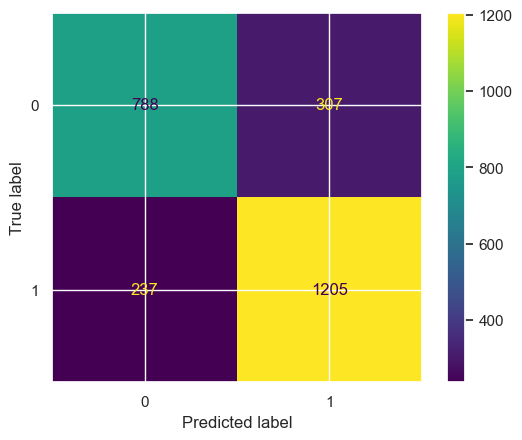

In [39]:
matrix=confusion_matrix(y_test,y_pred_xg)
disp=ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()
plt.show()

In [40]:
from sklearn.model_selection import cross_val_score
cv=cross_val_score(xgboost,x_train,y_train,cv=10)

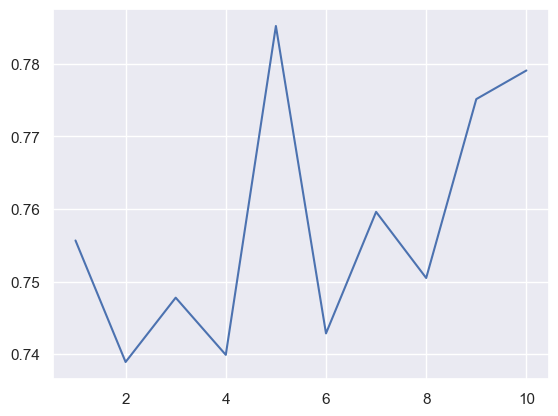

In [41]:
plt.plot(range(1,11),cv)

In [12]:
a=[[1,2,3],[4,5,6],[7,8,9]]
for i in a:
    for j in range(0,3):
        print(a[j][0])
    


[2]
[5]
[8]
[2]
[5]
[8]
[2]
[5]
[8]
